In [1]:
#!/bin/bash
! curl -L -o rockpaperscissors.zip\
  https://www.kaggle.com/api/v1/datasets/download/drgfreeman/rockpaperscissors

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  305M  100  305M    0     0  85.6M      0  0:00:03  0:00:03 --:--:--  120M


In [2]:
import zipfile

with zipfile.ZipFile('/content/rockpaperscissors.zip', 'r') as zip_ref:
  zip_ref.extractall('dataset')
  zip_ref.close()

In [3]:
!ls dataset

paper  README_rpc-cv-images.txt  rock  rps-cv-images  scissors


In [4]:
import os

len(os.listdir('/content/dataset/paper'))

712

In [5]:
len(os.listdir('/content/dataset/rock'))

726

In [6]:
len(os.listdir('/content/dataset/scissors'))

750

In [7]:
for item in os.listdir('/content/dataset'):
  print(item)

rps-cv-images
README_rpc-cv-images.txt
rock
scissors
paper


In [8]:
import shutil
shutil.rmtree('/content/dataset/rps-cv-images')

In [9]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [10]:
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'


In [11]:
device

'cuda'

In [13]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.relu = nn.ReLU(inplace=True)
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    return x

In [14]:
class UpConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
  def forward(self, x):
    return self.conv(x)

In [15]:
class UNet(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.up1 = UpConv(1024, 512)
    self.up2 = UpConv(512, 256)
    self.up3 = UpConv(256, 128)
    self.up4 = UpConv(128, 64)

    self.ContractingBlock1 = ConvBlock(in_channels=in_channels, out_channels=64)
    self.ContractingBlock2 = ConvBlock(64, 128)
    self.ContractingBlock3 = ConvBlock(128, 256)
    self.ContractingBlock4 = ConvBlock(256, 512)

    self.Bottleneck = ConvBlock(512, 1024)

    self.ExpandingBlock1 = ConvBlock(1024, 512)
    self.ExpandingBlock2 = ConvBlock(512, 256)
    self.ExpandingBlock3 = ConvBlock(256, 128)
    self.ExpandingBlock4 = ConvBlock(128, 64)

    self.Output = nn.Conv2d(64, out_channels=out_channels, kernel_size=1, stride=1)

  def forward(self, x):
    x = self.ContractingBlock1(x)
    result1 = x
    x = self.pool(x)

    x = self.ContractingBlock2(x)
    result2 = x
    x = self.pool(x)

    x = self.ContractingBlock3(x)
    result3 = x
    x = self.pool(x)

    x = self.ContractingBlock4(x)
    result4 = x
    x = self.pool(x)

    x = self.Bottleneck(x)

    x = self.up1(x)
    x = torch.cat((x, result4), dim=1)
    x = self.ExpandingBlock1(x)

    x = self.up2(x)
    x = torch.cat((x, result3), dim=1)
    x = self.ExpandingBlock2(x)

    x = self.up3(x)
    x = torch.cat((x, result2), dim=1)
    x = self.ExpandingBlock3(x)

    x = self.up4(x)
    x = torch.cat((x, result1), dim=1)
    x = self.ExpandingBlock4(x)

    x = self.Output(x)
    return x

In [16]:
def get_dice_score(outputs, labels, num_classes=4, smooth=1e-7):
  preds = torch.argmax(outputs, dim=1)

  dice_per_class = []
  for c in range(1, num_classes):
    pred_c = (preds== c).float().view(-1)
    label_c = (labels == c).float().view(-1)

    intersection =(pred_c * label_c).sum()
    dice =(2 * intersection + smooth) /(pred_c.sum() + label_c.sum() + smooth)
    dice_per_class.append(dice.item())

  return sum(dice_per_class) / len(dice_per_class)

In [17]:
def valid_unet(model, criterion, valid_loader, device):
  valid_losses = 0.
  valid_dice_scores = 0.
  model.eval()
  with torch.no_grad():
    for images, masks in valid_loader:
      images, masks = images.to(device), masks.to(device)
      pred_masks = model(images)
      loss = criterion(pred_masks, masks)
      dice_score = get_dice_score(pred_masks, masks)
      valid_losses += loss.item()
      valid_dice_scores += dice_score

    avg_valid_loss = valid_losses / len(valid_loader)
    avg_valid_dice_score = valid_dice_scores / len(valid_loader)

    return avg_valid_loss, avg_valid_dice_score

In [18]:
def train_unet(model, criterion, optimizer, train_loader, valid_loader, n_epochs, device, scheduler):
  history = { 'train_loss': [], 'train_dice': [], 'val_loss': [], 'val_dice': [], 'lr': [] }
  print(f"{'Epoch':^7} | {'Tr. Loss':^10} | {'Tr. Dice':^10} | {'Val Loss':^10} | {'Val Dice':^10} | {'LR':^10}")
  print("-" * 75)
  best_val_dice = 0.0

  for epoch in range(n_epochs):
      train_losses = 0.
      train_dice_scores = 0.
      model.train()
      current_lr = optimizer.param_groups[0]['lr']

      for images, masks in train_loader:
          images, masks = images.to(device), masks.to(device)
          pred_masks = model(images)
          optimizer.zero_grad()
          loss = criterion(pred_masks, masks)
          loss.backward()
          optimizer.step()
          dice_score = get_dice_score(pred_masks.detach(), masks)
          train_losses += loss.item()
          train_dice_scores += dice_score

      avg_train_loss = train_losses / len(train_loader)
      avg_train_dice_score = train_dice_scores / len(train_loader)
      avg_valid_loss, avg_valid_dice_score = valid_unet(model, criterion, valid_loader, device)

      if scheduler is not None:
          scheduler.step(avg_valid_loss)

      print(f"{epoch+1:^7} | {avg_train_loss:^10.4f} | {avg_train_dice_score:^10.4f} | "
            f"{avg_valid_loss:^10.4f} | {avg_valid_dice_score:^10.4f} | {current_lr:^10.1e}")

      if avg_valid_dice_score > best_val_dice:
          best_val_dice = avg_valid_dice_score
          torch.save(model.state_dict(), 'best_rps_model.pth')
          print(f"Model Saved! (New Best Val Dice: {best_val_dice:.4f}) ---")

      history['train_loss'].append(avg_train_loss)
      history['train_dice'].append(avg_train_dice_score)
      history['val_loss'].append(avg_valid_loss)
      history['val_dice'].append(avg_valid_dice_score)
      history['lr'].append(current_lr)

  return history

In [19]:
def plot_training_results(history):
  epochs = range(1, len(history['train_loss']) + 1)
  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
  plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epochs');
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.subplot(1, 2, 2)
  plt.plot(epochs, history['train_dice'], 'b-', label='Training Dice')
  plt.plot(epochs, history['val_dice'], 'r-', label='Validation Dice')
  plt.title('Training and Validation Dice Score')
  plt.xlabel('Epochs')
  plt.ylabel('Dice Score')
  plt.legend();
  plt.grid(True)

  plt.show()

In [21]:
import cv2

def create_hand_mask(image_bgr):
  hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

  lower_green = np.array([35, 40, 40])
  upper_green = np.array([85, 255,255])
  green_mask = cv2.inRange(hsv, lower_green, upper_green)
  hand_mask = cv2.bitwise_not(green_mask)

  kernel = np.ones((5,5), np.uint8)
  hand_mask = cv2.morphologyEx(hand_mask, cv2.MORPH_OPEN, kernel)
  hand_mask = cv2.morphologyEx(hand_mask, cv2.MORPH_CLOSE, kernel)

  return hand_mask

In [22]:
import glob
from PIL import Image
class RPSDataset(Dataset):
  def __init__(self, img_path, img_size=224):
    self.classes = ['rock', 'paper', 'scissors']
    self.img_files = []
    self.labels = []
    for i, cls in enumerate(self.classes):
      files = glob.glob(os.path.join(img_path, cls, "*.png"))
      self.img_files += files
      self.labels += [i + 1] * len(files)
      self.img_size = img_size
      self.img_transform = transforms.Compose([transforms.ToTensor()])

  def __len__(self):
    return len(self.img_files)

  def __getitem__(self, idx):
    img_path = self.img_files[idx]
    class_id = self.labels[idx]

    image_bgr = cv2.imread(img_path)
    image_bgr = cv2.resize(image_bgr, (self.img_size, self.img_size))

    hand_mask = create_hand_mask(image_bgr)
    hand_binary = (hand_mask > 127).astype(np.int64)

    class_mask = hand_binary * class_id

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_tensor = self.img_transform(Image.fromarray(image_rgb))
    mask_tensor = torch.from_numpy(class_mask).long()

    return image_tensor, mask_tensor

In [23]:
dataset = RPSDataset(img_path= '/content/dataset', img_size=224)

In [24]:
torch.manual_seed(42)

n_total = len(dataset)
n_train = int(n_total * 0.8)
n_val = int(n_total * 0.1)
n_test = n_total - n_train - n_val

In [25]:
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])

In [26]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(val_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [28]:
images, masks = next(iter(train_loader))

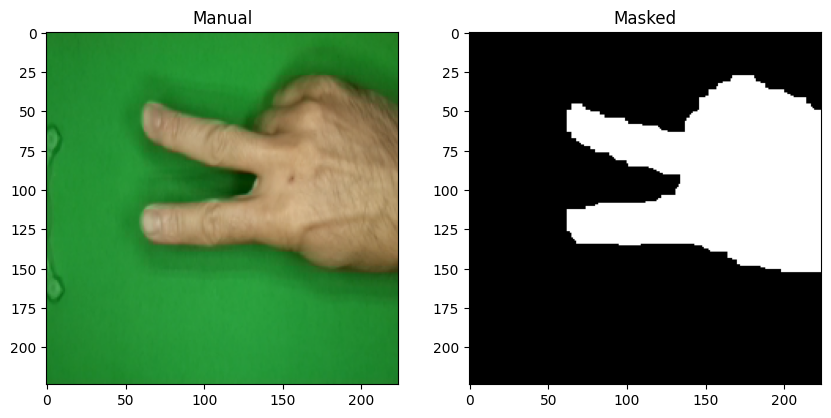

In [29]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Manual")

plt.subplot(1, 2, 2)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Masked")
plt.show()

In [30]:
model = UNet(in_channels=3, out_channels=4).to(device)
criterion = nn.CrossEntropyLoss()
n_epochs =10


In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [32]:
history  = train_unet(
    model=model, criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=n_epochs,
    device=device,
    scheduler=scheduler
)

 Epoch  |  Tr. Loss  |  Tr. Dice  |  Val Loss  |  Val Dice  |     LR    
---------------------------------------------------------------------------
   1    |   1.0049   |   0.0185   |   0.4795   |   0.1739   |  1.0e-04  
Model Saved! (New Best Val Dice: 0.1739) ---
   2    |   0.4287   |   0.1833   |   0.3701   |   0.2198   |  1.0e-04  
Model Saved! (New Best Val Dice: 0.2198) ---
   3    |   0.3684   |   0.2015   |   0.3603   |   0.1891   |  1.0e-04  
   4    |   0.3648   |   0.2092   |   0.3580   |   0.1850   |  1.0e-04  
   5    |   0.3621   |   0.2190   |   0.3563   |   0.2392   |  1.0e-04  
Model Saved! (New Best Val Dice: 0.2392) ---
   6    |   0.3603   |   0.2815   |   0.3531   |   0.3385   |  1.0e-04  
Model Saved! (New Best Val Dice: 0.3385) ---
   7    |   0.3548   |   0.3046   |   0.3246   |   0.3568   |  1.0e-04  
Model Saved! (New Best Val Dice: 0.3568) ---
   8    |   0.2877   |   0.4481   |   0.2232   |   0.6836   |  1.0e-04  
Model Saved! (New Best Val Dice: 0.6836) -

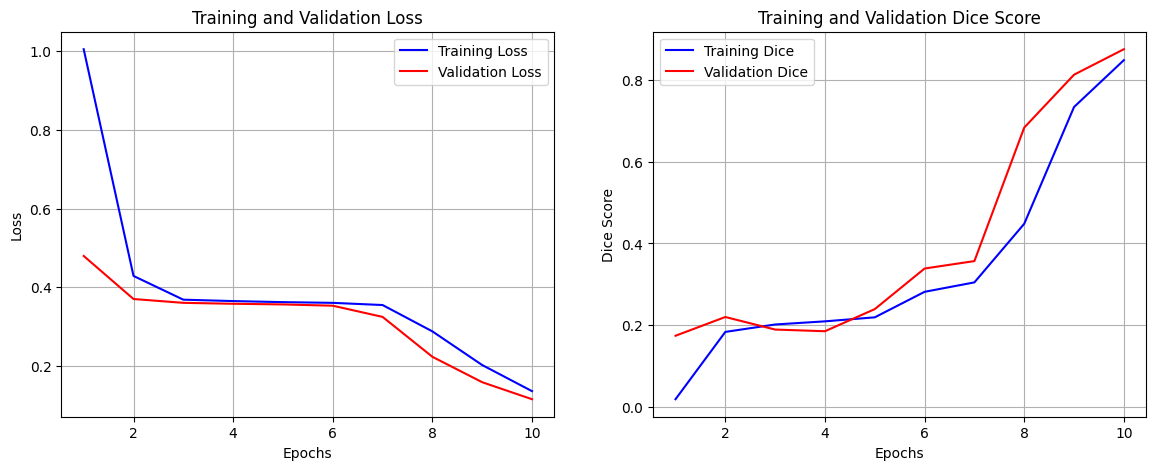

In [33]:
plot_training_results(history)

In [34]:
def visualize_predictions(model, valid_loader, device, num_batches=10, save_path="rps_unet_results.png"):
  model.eval()
  all_images, all_masks, all_preds = [], [], []
  with torch.no_grad():
      for i, (images, masks) in enumerate(valid_loader):
          if i >= num_batches:
              break
          images, masks = images.to(device), masks.to(device)
          outputs = model(images)
          preds = torch.argmax(outputs, dim=1)

          all_images.append(images[0].cpu())
          all_masks.append(masks[0].cpu())
          all_preds.append(preds[0].cpu())

  num_samples = len(all_images)
  fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
  if num_samples == 1:
      axes = [axes]

  for i in range(num_samples):
      axes[i][0].imshow(all_images[i].permute(1, 2, 0))
      axes[i][0].set_title(f"Sample {i+1}: Orijinal")
      axes[i][0].axis('off')

      axes[i][1].imshow(all_masks[i], cmap='tab10', vmin=0, vmax=3)
      axes[i][1].set_title(f"Sample {i+1}: Automatik Masking")
      axes[i][1].axis('off')

      axes[i][2].imshow(all_preds[i], cmap='tab10', vmin=0, vmax=3)
      axes[i][2].set_title(f"Sample {i+1}: Model Prediction")
      axes[i][2].axis('off')

  plt.tight_layout()
  plt.savefig(save_path, bbox_inches='tight', dpi=300)
  print(f"Saved the results: {save_path}")
  plt.show()

Saved the results: rps_unet_inference.png


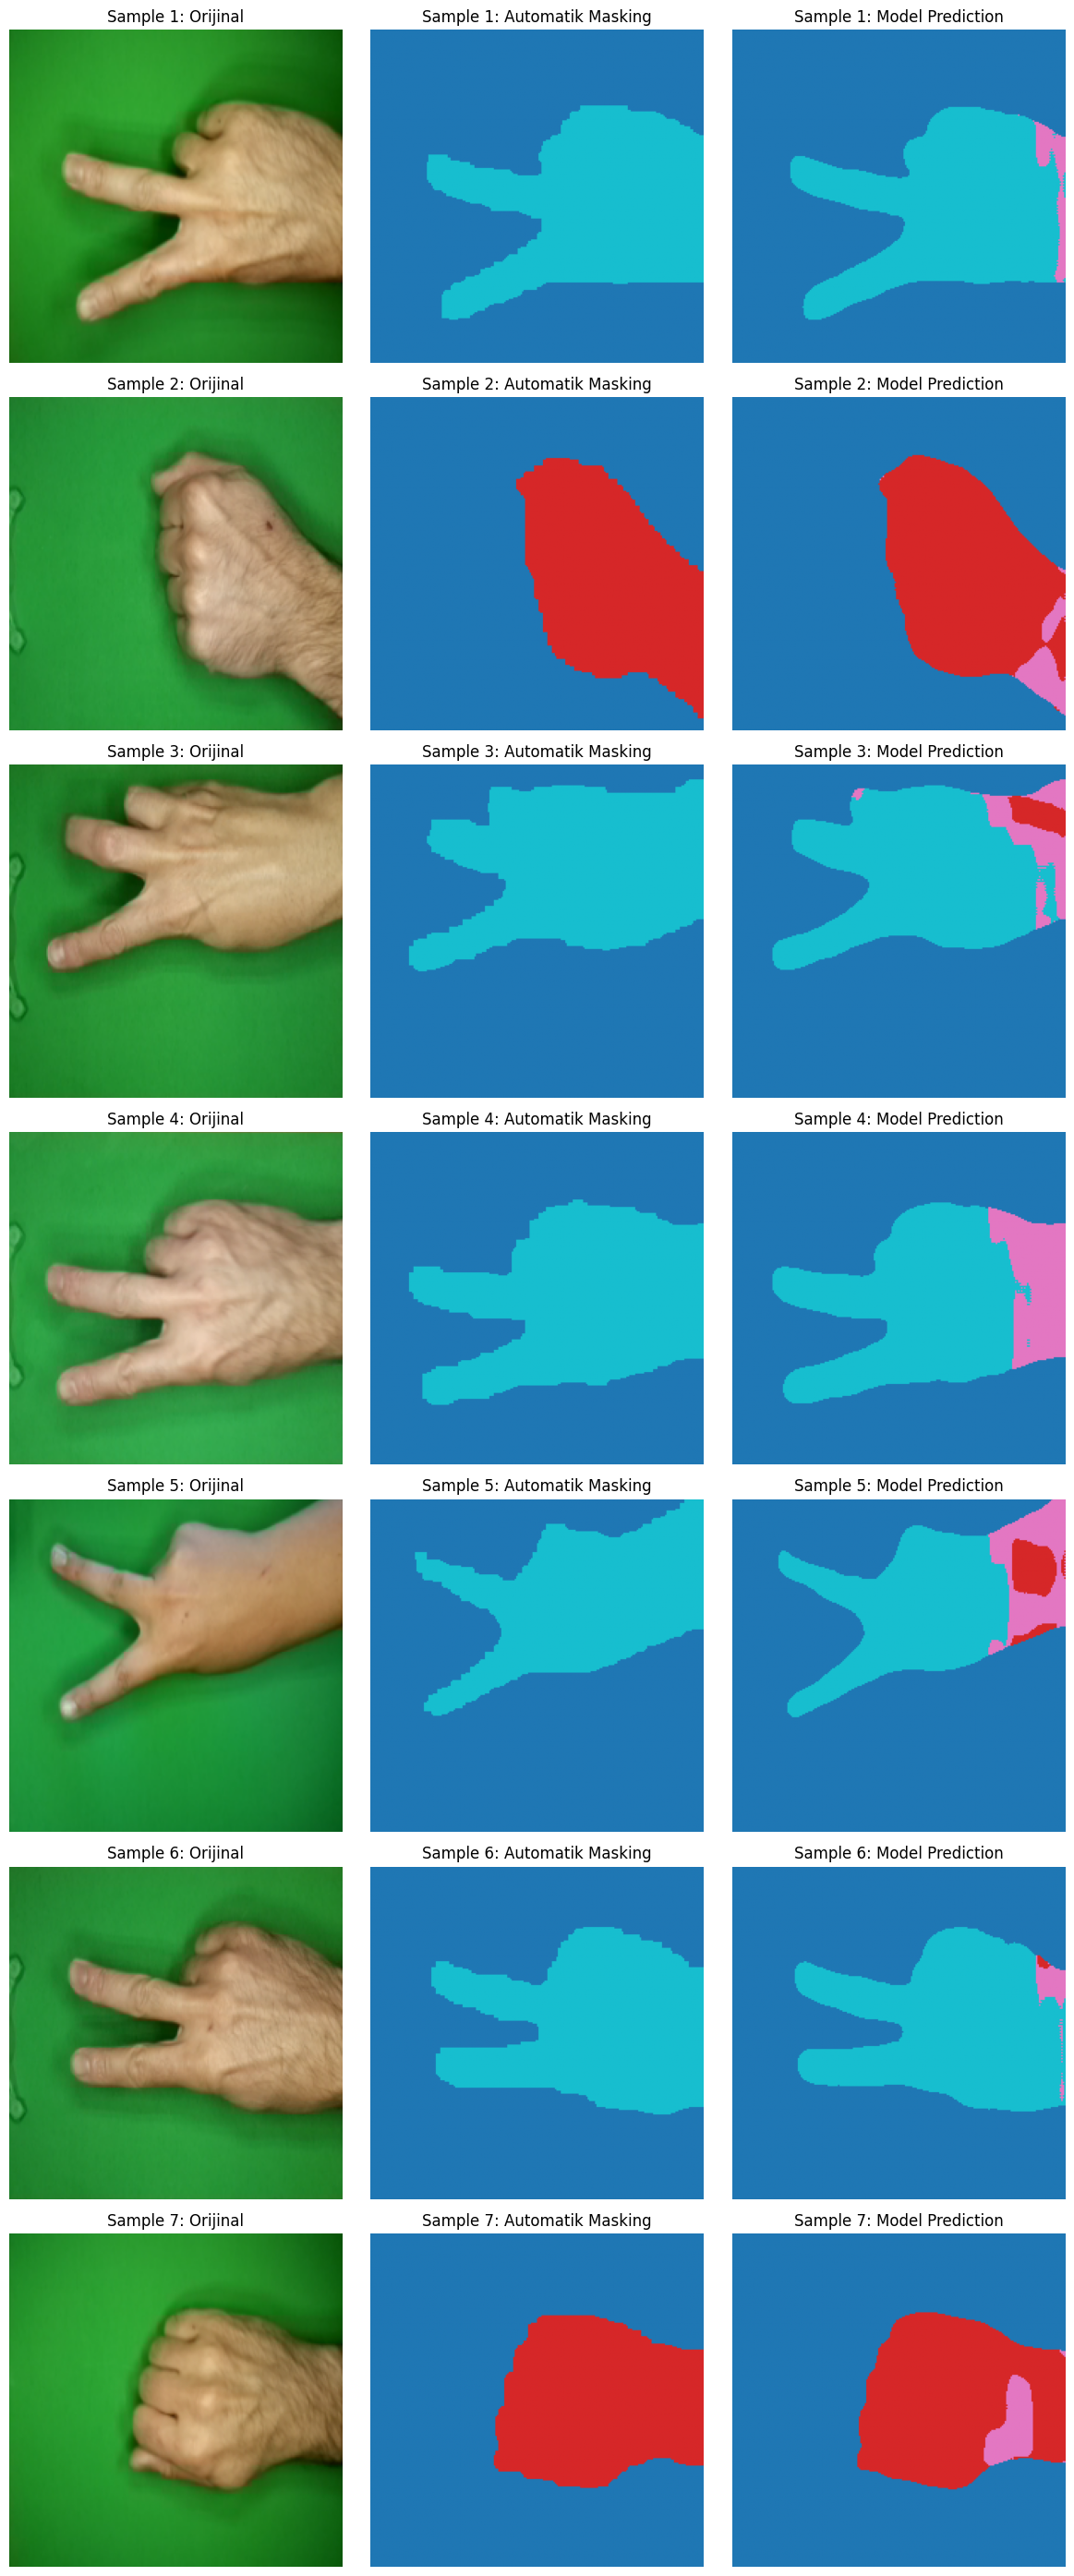

In [35]:
visualize_predictions(model, valid_loader, device, num_batches=10, save_path='rps_unet_inference.png')